Import libraris

In [31]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [3]:
df =pd.read_csv(r"C:\Users\Mohamed-Hamdy\OneDrive\Desktop\crimes.csv")
df
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247988 entries, 0 to 247987
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         247988 non-null  int64 
 1   Date Rptd     247988 non-null  object
 2   DATE OCC      247988 non-null  object
 3   TIME OCC      247988 non-null  int64 
 4   AREA NAME     247988 non-null  object
 5   Crm Cd Desc   247988 non-null  object
 6   Vict Age      247988 non-null  int64 
 7   Vict Sex      215740 non-null  object
 8   Vict Descent  215739 non-null  object
 9   Weapon Desc   80087 non-null   object
 10  Status Desc   247988 non-null  object
 11  LOCATION      247988 non-null  object
dtypes: int64(3), object(9)
memory usage: 22.7+ MB


check duplicate


In [8]:
df.duplicated().sum()

0

check  null value


In [4]:
df.isna().sum()

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex         32248
Vict Descent     32249
Weapon Desc     167901
Status Desc          0
LOCATION             0
dtype: int64

fill null in colom 


In [5]:
df["Vict Sex"].fillna("Unknown",inplace=True)
df["Vict Sex"].isna().sum()
df["Weapon Desc"].fillna("Unknown",inplace=True)
df["Weapon Desc"].isna().sum()
df["Vict Descent"].fillna(df["Vict Descent"].mode()[0],inplace=True)

Check coloms after filling null 

In [6]:
df.isna().sum()

DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA NAME       0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Weapon Desc     0
Status Desc     0
LOCATION        0
dtype: int64

Convert Time from 1234  ---> 24 H

In [7]:
df["hour_occ"] = df["TIME OCC"] // 100
df["hour_occ"]
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,hour_occ
0,221412410,2022-06-15,2020-11-12,1700,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0,Unknown,H,Unknown,Invest Cont,13600 MARINA POINT DR,17
1,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,Unknown,Invest Cont,2500 S SYCAMORE AV,11
2,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,Unknown,Invest Cont,3300 SAN MARINO ST,16
3,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,Unknown,Invest Cont,1900 TRANSIENT,12
4,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,Unknown,Invest Cont,6200 4TH AV,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247983,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,Unknown,Invest Cont,5300 DENNY AV,11
247984,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,Unknown,Invest Cont,12500 BRANFORD ST,18
247985,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST,10
247986,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV,16


clean age colom 

In [ ]:
df["Vict Age"] = pd.to_numeric(df["Vict Age"], errors="coerce")
df = df[(df["Vict Age"].notna()) & (df["Vict Age"] > 0) & (df["Vict Age"] != 99)].copy()
df["Vict Age"]

1         27
2         60
3         28
4         37
5         79
          ..
247983    25
247984    23
247985    25
247986    29
247987    53
Name: Vict Age, Length: 185610, dtype: int64

Charts and requierment
1. Peak Crime Hour
2. Night Crime Geography
3. Victim Demographics
4. Anomaly Detection on Victim Age

1. Peak Crime Hour

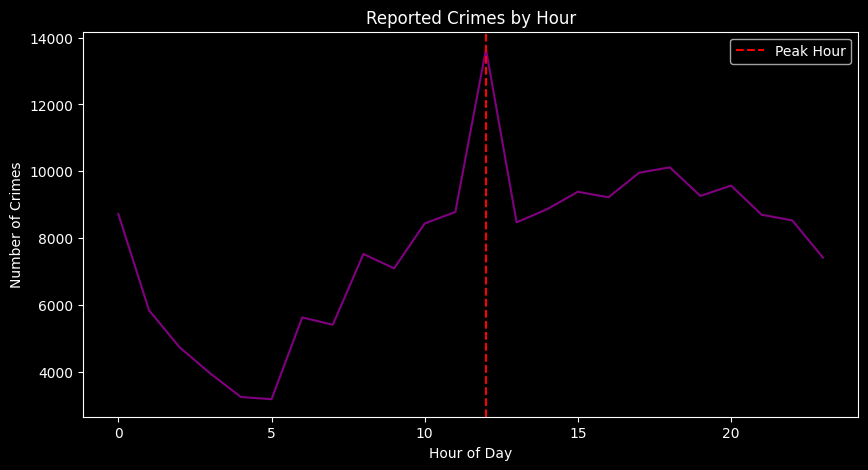

In [53]:
hour_counts = df["hour_occ"].value_counts().sort_index()
crime_hour = hour_counts.idxmax()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, color="purple")
plt.axvline(crime_hour, color="red", linestyle="--", label="Peak Hour")
plt.title("Reported Crimes by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.legend()
plt.style.use("dark_background")
plt.show()




2. Night Crime Geography

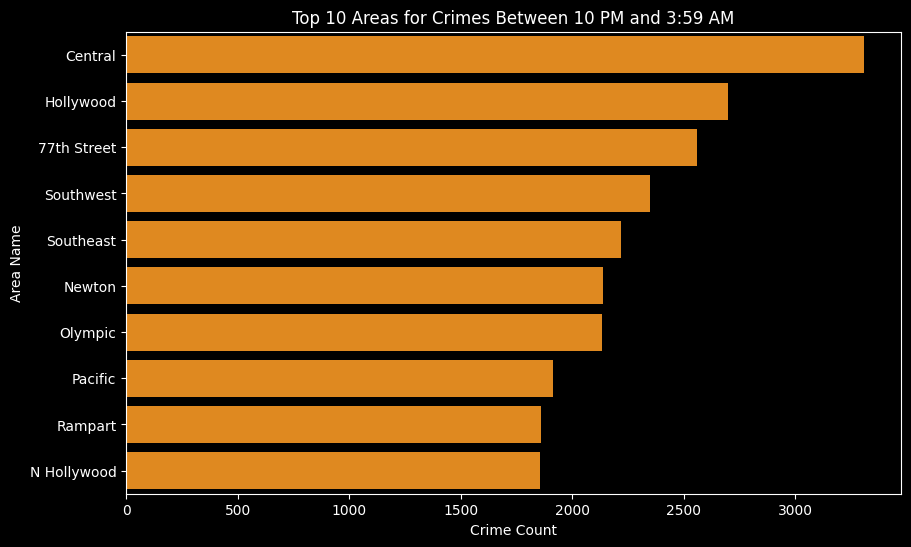

In [15]:
night = (df["hour_occ"] >= 22) | (df["hour_occ"] <= 3)
night_area_counts = df.loc[night, "AREA NAME"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=night_area_counts.head(10).values, y=night_area_counts.head(10).index, color="darkorange")
plt.title("Top 10 Areas for Crimes Between 10 PM and 3:59 AM")
plt.xlabel("Crime Count")
plt.ylabel("Area Name")
plt.show()

3. Victim Demographics

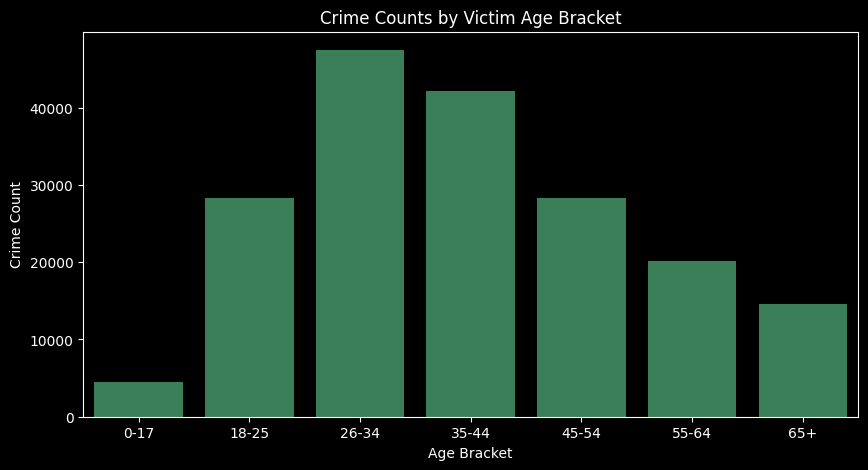

In [61]:
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]
df["age group"] = pd.cut(
    df["Vict Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)
victim_ages = df["age group"].value_counts().reindex(age_labels, fill_value=0)
plt.figure(figsize=(10, 5))
sns.barplot(x=victim_ages.index, y=victim_ages.values, color="seagreen")
plt.title("Crime Counts by Victim Age Bracket")
plt.xlabel("Age Bracket")
plt.ylabel("Crime Count")
plt.show()


In [28]:
df.corr(numeric_only=True)

,DR_NO,TIME OCC,Vict Age,hour_occ
DR_NO,1.000000,0.026617,0.011740,0.026608
TIME OCC,0.026617,1.000000,-0.014455,0.999619
Vict Age,0.011740,-0.014455,1.000000,-0.013180
hour_occ,0.026608,0.999619,-0.013180,1.000000


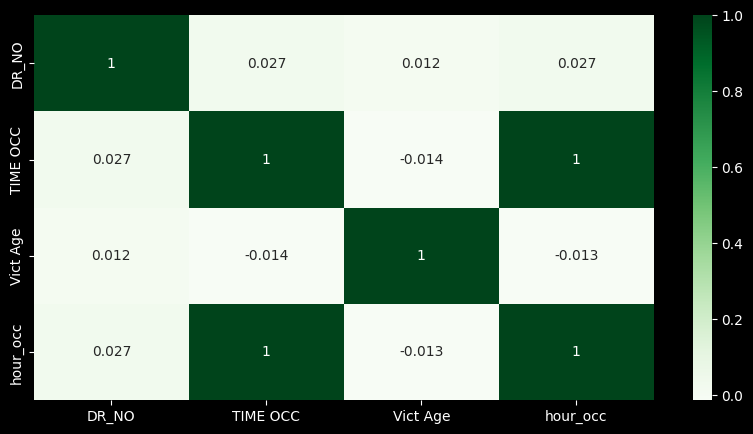

In [29]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Greens")
plt.show()

4. Anomaly Detection on Victim Age

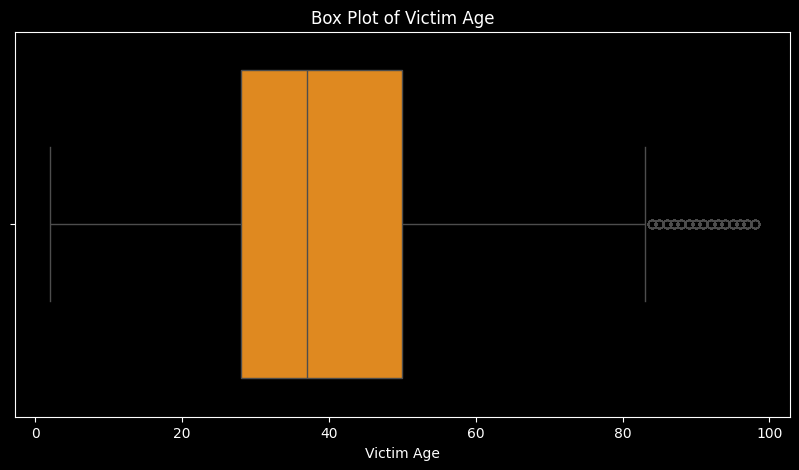

In [40]:
q1 = df["Vict Age"].quantile(0.25)
q3 = df["Vict Age"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#age_outliers = df[
#    (df["Vict Age"] < lower_bound) | (df["Vict Age"] > upper_bound)
#]["Vict Age"]

#print("Q3 =", q3)
#print("IQR =", iqr)
#print("Lower bound =", lower_bound)
#print("Upper bound =", upper_bound)
#print("Outlier ages")
#print(age_outliers.value_counts().sort_index())
#كنت بجرب حاجه  كدا 

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Vict Age"], color="darkorange")
plt.title("Box Plot of Victim Age")
plt.xlabel("Victim Age")
plt.show()


Extra

<function matplotlib.pyplot.show(close=None, block=None)>

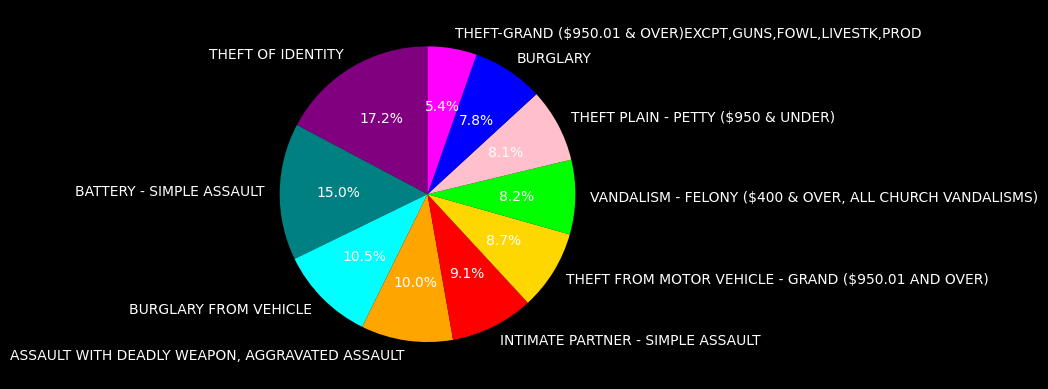

In [59]:
top_crimes = df["Crm Cd Desc"].value_counts().head(10)
colors = [
    "purple",
    "teal",
    "cyan",
    "orange",
    "red",
    "gold",
    "lime",
    "pink",
    "blue",
    "magenta"
]
plt.pie(
    top_crimes.values,
    labels=top_crimes.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)
plt.show
